<div >
<img src = "../banner.jpg" />
</div>

<a target="_blank" href="https://colab.research.google.com/github/ignaciomsarmiento/BDML_202610/blob/main/Lecture08/Notebook_LDA.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



# Linear Discriminant Analysis (LDA)

**LDA** is a generative classifier: instead of modeling $Pr(Y=k|X)$ directly, it models the distribution of $X$ within each class and then applies Bayes' rule to recover the posterior.

LDA makes two assumptions:
1. Each class-conditional distribution follows a **Normal distribution**: $X|Y=k \sim N(\mu_k, \Sigma)$.
2. All classes share the **same covariance matrix** $\Sigma$ .



## The Classifier

Applying Bayes' rule:

\begin{align}
p(Y=1|X) = \frac{\overbrace{f(X|Y=1)}^{\text{likelihood}} \cdot \overbrace{p(Y=1)}^{\text{prior}}}{\underbrace{m(X)}_{\text{normalisation}}}
\end{align}

where $m(X)$ is the marginal density of $X$, a normalising constant that ensures probabilities sum to 1:

\begin{align}
m(X) = f(X|Y=1)\,p(Y=1) + f(X|Y=0)\,p(Y=0)
\end{align}

We need to estimate three quantities from data: $f(X|Y=1)$, $f(X|Y=0)$, and $p(Y=1)$.

## By Hand

We apply LDA to predict unemployment using `edad` (age) as the single predictor. The goal is to compute posterior probabilities $p(Y=1|X)$ manually, then verify against R's `lda()` from `MASS`.

In [1]:
#Cargar librerías 
require("pacman")
p_load(tidyverse)
set.seed(1011)

Loading required package: pacman



In [2]:
#Leer los datos 
db <- readRDS(url("https://github.com/ignaciomsarmiento/datasets/blob/main/desempelo_arg_2010.Rds?raw=true"))
head(db)

desempleado,edad,mujer,parentesco,nivel_ed,estado_civil,total_miembros_hogar,miembros_hogar_menores10,ing_tot_fam,tipo_vivienda,ciudad,trimestre,id_hogar
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<chr>
0,49,0,Hijo/a - Hijastro/a,Superior Universitaria Incompleta,Soltero/a,2,0,4200,Casa,Gran Rosario,1,1250021
0,56,1,Jefe/a,Primaria Completa,Viudo/a,1,0,1380,Departamento,Rio Cuarto,1,1250241
0,31,0,Jefe/a,Superior Universitaria Incompleta,Unido/a,3,1,8400,Casa,Partidos del GBA,1,1251051
0,33,1,Conyuge/Pareja,Superior Universitaria Completa,Unido/a,3,1,8400,Casa,Partidos del GBA,1,1251051
0,40,1,Hijo/a - Hijastro/a,Secundaria Completa,Unido/a,5,2,8800,Casa,Gran Cordoba,1,1251161
0,49,0,Yerno/Nuera,Secundaria Completa,Unido/a,5,2,8800,Casa,Gran Cordoba,1,1251161


### Step 1. Prior $p(Y=1)$

Estimated as the sample proportion of unemployed individuals:

\begin{align}
\hat{p}(Y=1) = \frac{\sum_{i=1}^n \mathbf{1}[Y_i=1]}{N}
\end{align}

In [3]:
p1 <- sum(db$desempleado) / nrow(db)
p1

[1] 0.07260696

### Step 2. Class-conditional likelihoods $f(X|Y=k)$

Under LDA, $X|Y=k \sim N(\mu_k, \sigma)$. We need to estimate:
- $\hat{\mu}_k$: the mean of `edad` within each class.
- $\hat{\sigma}$: a **single pooled standard deviation** shared across classes.

The pooled $\hat{\sigma}$ is what makes the boundary linear: both Gaussians have the same spread, so they can only differ in location, and the point where they cross is a straight line (in 1D, a single threshold).

**Class means** — sample average of $X$ within each class:

\begin{align}
\hat{\mu}_k = \frac{1}{n_k}\sum_{i:\,y_i=k} x_i
\end{align}

In [4]:
mu1 <- mean(db$edad[db$desempleado == 1])  # mean age | unemployed
mu0 <- mean(db$edad[db$desempleado == 0])  # mean age | employed

cat("mu1 (unemployed):", round(mu1, 2), "\nmu0 (employed):  ", round(mu0, 2))

mu1 (unemployed): 31.19 
mu0 (employed):   38.64

**Pooled variance** — within-class sum of squared deviations, divided by $N - K$ (degrees of freedom):

\begin{align}
\hat{\sigma}^2 = \frac{1}{N-K} \sum_{k=1}^K \sum_{i:\,y_i=k} (x_i - \hat{\mu}_k)^2
\end{align}

This is the within-class variance pooled across all $K$ classes. Using $N-K$ (not $N$) corrects for the $K$ estimated means.

In [5]:
# Within-class sum of squares for each class
ss1 <- sum((db$edad[db$desempleado == 1] - mu1)^2)
ss0 <- sum((db$edad[db$desempleado == 0] - mu0)^2)

# Pooled standard deviation (N - K = N - 2 degrees of freedom)
sigma <- sqrt((ss1 + ss0) / (nrow(db) - 2))
sigma

[1] 12.23914

With $\hat{\mu}_k$ and $\hat{\sigma}$ we can evaluate the Gaussian density for every observation under each class hypothesis:

In [6]:
f1 <- dnorm(db$edad, mean = mu1, sd = sigma)  # f(edad | Y=1, unemployed)
f0 <- dnorm(db$edad, mean = mu0, sd = sigma)  # f(edad | Y=0, employed)

### Step 3. Posterior via Bayes' rule

Plug the likelihoods and prior into the formula:

\begin{align}
\hat{p}(Y=1|X) = \frac{f(X|Y=1)\,\hat{p}(Y=1)}{f(X|Y=1)\,\hat{p}(Y=1) + f(X|Y=0)\,(1-\hat{p}(Y=1))}
\end{align}

In [7]:
post_hand <- f1 * p1 / (f1 * p1 + f0 * (1 - p1))
head(post_hand)

[1] 0.03740933 0.02670463 0.08686852 0.07929581 0.05731898 0.03740933

## Verification: `lda()` from MASS

R's `lda()` implements exactly the same estimator. We run it and compare its posterior probabilities against our manual calculation — they should be identical.

In [8]:
p_load("MASS")

lda_simple      <- lda(desempleado ~ edad, data = db)
lda_simple_pred <- predict(lda_simple, db)

# predict() returns a list; $posterior contains Pr(Y=k | x_i) for each observation
names(lda_simple_pred)

[1] "class"     "posterior" "x"

In [9]:
# Compare: column `1` from lda() should equal our hand-computed posterior
posteriors        <- data.frame(lda_simple_pred$posterior)
posteriors$hand   <- post_hand

head(posteriors)

,X0,X1,hand
,<dbl>,<dbl>,<dbl>
1,0.9625907,0.03740933,0.03740933
2,0.9732954,0.02670463,0.02670463
3,0.9131315,0.08686852,0.08686852
4,0.9207042,0.07929581,0.07929581
5,0.9426810,0.05731898,0.05731898
6,0.9625907,0.03740933,0.03740933



The columns from `lda()` and `hand` are identical, confirming that our three-step derivation is exactly what `lda()` computes under the hood.




# HW: Quadratic Discriminant Analysis (QDA)

LDA assumes all classes share the same covariance matrix $\Sigma$. **QDA relaxes this**: each class gets its own covariance matrix $\Sigma_k$.

The posterior is still computed via Bayes' rule:

\begin{align}
p(Y=k|X) = \frac{f_k(X)\,p(Y=k)}{\sum_{j} f_j(X)\,p(Y=j)}
\end{align}

but now $f_k(X) = \mathcal{N}(X;\,\mu_k,\,\sigma_k)$, with a **class-specific** $\sigma_k$ instead of the shared $\sigma$.

This makes the decision boundary **quadratic** in $X$: two Gaussians with different spreads cross at two points, not one.


Follow the same three steps as LDA. The only difference is in Step 2.

### Step 1.Prior $p(Y=1)$

Same as LDA. You already have `p1`; no need to recompute it.

### Step 2. Class-specific variances

Instead of a single pooled $\hat{\sigma}$, estimate one standard deviation **per class**:

\begin{align}
\hat{\sigma}_k^2 = \frac{1}{n_k - 1} \sum_{i:\,y_i=k} (x_i - \hat{\mu}_k)^2 \qquad k = 0, 1
\end{align}

Note the denominator is $n_k - 1$ (degrees of freedom within each class), not $N - K$.

**Your turn:** compute `sigma1` and `sigma0` using `db$edad` and the means `mu1`, `mu0` already estimated above.

In [10]:
# sigma1 <- ...   standard deviation of edad within the unemployed group
# sigma0 <- ...   standard deviation of edad within the employed group

### Step 3. Class-conditional likelihoods

Now evaluate the Gaussian density for each observation under each class, using the **class-specific** standard deviation:

\begin{align}
\hat{f}_k(x_i) = \frac{1}{\hat{\sigma}_k\sqrt{2\pi}}\,\exp\!\left(-\frac{(x_i - \hat{\mu}_k)^2}{2\hat{\sigma}_k^2}\right)
\end{align}

**Your turn:** compute `f1_qda` and `f0_qda` using `dnorm()` with `sigma1` and `sigma0` respectively.

In [11]:
# f1_qda <- dnorm(...)   likelihood under class 1 (unemployed), using sigma1
# f0_qda <- dnorm(...)   likelihood under class 0 (employed),   using sigma0

### Step 4. Posterior via Bayes' rule

The formula is identical to LDA — only the likelihoods change:

\begin{align}
\hat{p}(Y=1|X) = \frac{\hat{f}_1(X)\,\hat{p}(Y=1)}{\hat{f}_1(X)\,\hat{p}(Y=1) + \hat{f}_0(X)\,(1-\hat{p}(Y=1))}
\end{align}

**Your turn:** compute `post_qda` and print the first few values.

In [12]:
# post_qda <- ...

### Verification: `qda()` from MASS

Run `qda()` and compare its posteriors against `post_qda`. If your implementation is correct, the columns should match.


In [13]:
# qda_simple      <- qda(...)
# qda_simple_pred <- predict(...)

# posteriors_qda        <- data.frame(qda_simple_pred$posterior)
# posteriors_qda$hand   <- post_qda
# head(posteriors_qda)

## Logistic Regression: decision boundary in the X-space

Using raw `ing_tot_fam` is not very informative here because family income is extremely right-skewed, and with the 0.5 rule the fitted boundary falls outside most of the visible support.

To make the geometry visible, we work with `log(1 + ing_tot_fam)` on the vertical axis. With predictors `edad` and `log(1 + ing_tot_fam)`, the logit boundary is given by

\begin{align}
\hat{\beta}_0 + \hat{\beta}_1 \, edad + \hat{\beta}_2 \, \log(1 + ing\_tot\_fam) = 0
\end{align}

which is a straight line in this transformed predictor space.


In [14]:
db_logit <- db %>%
  dplyr::select(desempleado, edad, ing_tot_fam) %>%
  tidyr::drop_na() %>%
  dplyr::mutate(log_ing_tot_fam = log1p(ing_tot_fam))

logit_2d <- glm(desempleado ~ edad + log_ing_tot_fam, data = db_logit, family = binomial())


In [15]:
grid <- expand_grid(
  edad = seq(min(db_logit$edad), max(db_logit$edad), length.out = 200),
  log_ing_tot_fam = seq(min(db_logit$log_ing_tot_fam), max(db_logit$log_ing_tot_fam), length.out = 200)
)

grid$p_hat <- predict(logit_2d, newdata = grid, type = "response")
grid$class_hat <- factor(ifelse(grid$p_hat >= 0.5, 1, 0))


In [16]:
b <- coef(logit_2d)
boundary_intercept <- -b[1] / b[3]
boundary_slope <- -b[2] / b[3]
ymax_plot <- quantile(db_logit$log_ing_tot_fam, 0.25)


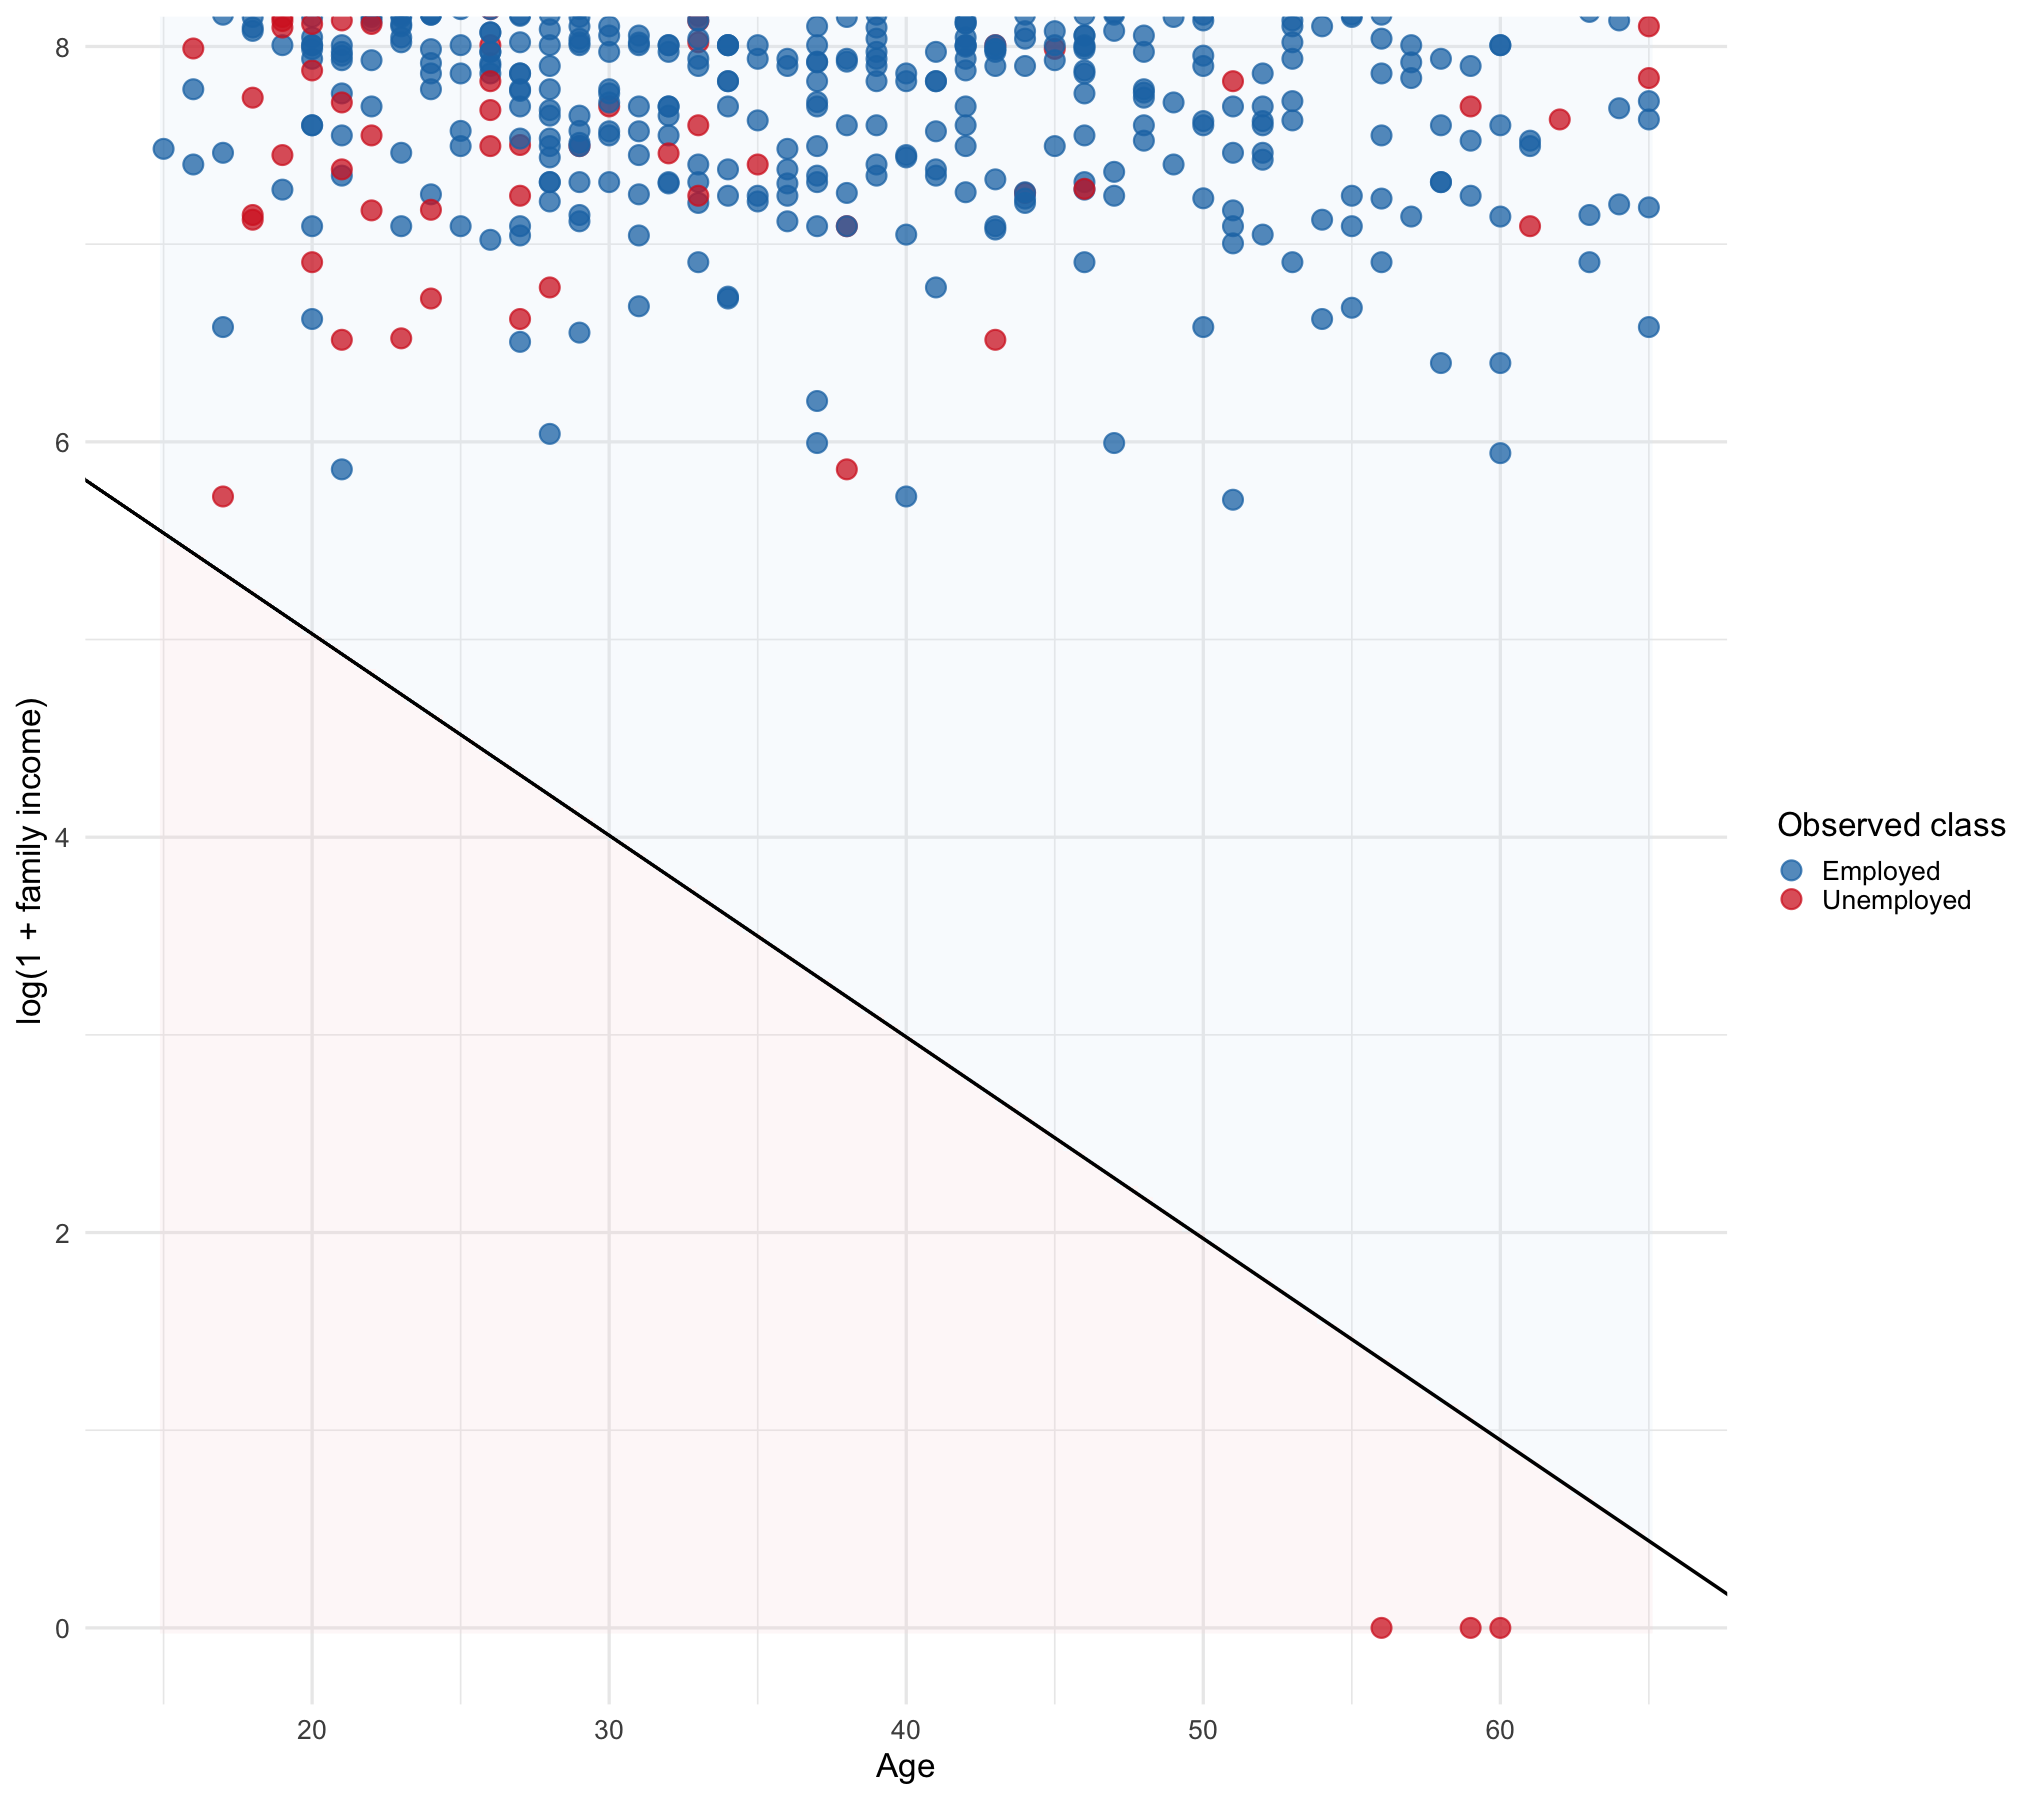

In [17]:
options(repr.plot.width = 17, repr.plot.height = 15)

ggplot() +
  geom_raster(
    data = grid,
    aes(x = edad, y = log_ing_tot_fam, fill = class_hat),
    alpha = 0.18
  ) +
  geom_point(
    data = db_logit[1:800,],
    aes(x = edad, y = log_ing_tot_fam, color = factor(desempleado)),
    alpha = 0.75, size = 5
  ) +
  geom_abline(
    intercept = boundary_intercept,
    slope = boundary_slope,
    color = "black", linewidth = 1
  ) +
  scale_fill_manual(values = c("0" = "#dceaf7", "1" = "#f8d7da"), guide = "none") +
  scale_color_manual(
    values = c("0" = "#1f77b4", "1" = "#d62728"),
    labels = c("0" = "Employed", "1" = "Unemployed")
  ) +
  coord_cartesian(ylim = c(0, ymax_plot)) +
  labs(
    x = "Age",
    y = "log(1 + family income)",
    color = "Observed class"
  ) +
  theme_minimal(base_size = 20)


## HW: decision boundaries for LDA and QDA

Repeat the same figure for `lda()` and `qda()` 